# Earnings revision screen

**Leland Degas Wright · Atlanta, GA · 8 October 2026**

A ranking of 77 U.S. large-cap growth stocks on four inputs an investment analyst can explain: EPS surprise consistency, the recent path of consensus EPS estimates, EPS growth acceleration, and a growth-at-a-reasonable-price valuation check. A separate backtest asks whether *trailing EPS surprises alone*, using only information known at each quarter-end, lined up with later returns.

This notebook is an educational exercise for interview practice. It is not a recommendation to buy or sell any security.

The calculations live in `earnings_screen.py`, with comments on each choice. This notebook runs that pipeline from the cached CSV files (no network), then shows the tables, the SQL, and the charts. Figures below match `README.md` for the 8 October 2026 cache.


## 1. Question

For a U.S. large-cap growth coverage universe, measured against the Russell 1000 Growth:

1. Which names are beating EPS estimates, and is that a habit?
2. Are analysts raising the consensus, or cutting it?
3. Is the EPS growth rate speeding up, or only still positive?
4. Is the multiple reasonable for that growth?

The composite is a reading list. The backtest covers only question 1, because free data has no history of the consensus or of forward P/E.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "earnings_screen.py").exists():
    ROOT = Path("/workspace/01-earnings-revision-screen")
sys.path.insert(0, str(ROOT))

import earnings_screen as es

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

# Reads data/raw/. Does not download unless force_download=True.
result = es.run(force_download=False)
scores = result["scores"]
earnings = result["earnings"]
stats = result["stats"]
quarterly = result["quarterly"]
panel = result["panel"]
summary = result["summary"]
print("As-of date:", summary["quality"]["asof"])
print("Names scored:", int(scores["composite"].notna().sum()))


Using cached raw files in data/raw/


{
  "quality": {
    "asof": "2026-10-08",
    "n_universe": 77,
    "n_reported_rows": 1839,
    "n_usable_surprises": 1784,
    "n_dropped_tiny_or_negative_estimate": 55,
    "n_surprise_capped": 191,
    "median_abs_surprise_vs_vendor": 0.15347826086956218,
    "surprise_start": "2020-10-14",
    "surprise_end": "2026-10-01",
    "n_scored": 77,
    "n_unscored": 0,
    "median_beat_rate": 0.875,
    "median_avg_surprise": 6.077963267779046
  },
  "spread": {
    "n_quarters": 20,
    "mean_q5_minus_q1": 0.012912141700057705,
    "tstat_descriptive": 0.611126835423192,
    "first_rebalance": "2021-09-30",
    "last_rebalance": "2026-06-30",
    "last_period_end": "2026-09-30"
  },
  "sklearn": {
    "train_end_exclusive": "2024-03-31",
    "n_train": 727,
    "n_test": 769,
    "coef_train_excess_per_z": -0.00013286698077846022,
    "intercept_train": -4.279005706560562e-18,
    "r2_test": -1.557679477293128e-05,
    "coef_full_sample": 0.0012088886721793,
    "q5_minus_q1_excess_fi

## 2. Universe

The list is `data/universe.csv`: 77 U.S. issuers with a large-cap growth profile, fixed so the project does not scrape an index provider. It is not official Nasdaq-100 or Russell 1000 Growth membership. Sectors are the Yahoo Finance labels. Three U.S.-listed companies incorporated abroad (NXP, Medtronic, Eaton) are in the raw cache and are excluded here, so the study stays with U.S. issuers.


In [2]:
snap = scores.groupby("sector").size().rename("names").sort_values(ascending=False)
display(snap.to_frame())
print("Top 20 that are Technology:", int((scores.nsmallest(20, "rank")["sector"] == "Technology").sum()), "of 20")


,names
sector,
Technology,32
Consumer Cyclical,12
Healthcare,11
Communication Services,7
Financial Services,6
Industrials,5
Consumer Defensive,4


Top 20 that are Technology: 12 of 20


## 3. What the cache contains, and what was cleaned

Surprise history is real, from late 2020 through the latest reported quarter. Estimate revisions and valuation are a snapshot. The cleaning that matters:

- After-close prints (4:00 p.m. New York or later) become available the next business day.
- Surprise % is recomputed as `(reported − estimate) / estimate × 100`. The median absolute gap versus Yahoo's own field is a few tenths of a point.
- Estimates below $0.05, and negative estimates, are dropped. Remaining surprises are capped at ±25%.
- Year-over-year growth is matched to the quarter about a year earlier on the calendar, not "four rows up," so a gap in the file cannot masquerade as a year.


In [3]:
q = summary["quality"]
rows = pd.Series({
    "As of": q["asof"],
    "Universe": q["n_universe"],
    "Reported quarters kept": q["n_reported_rows"],
    "Usable surprises": q["n_usable_surprises"],
    "Dropped (tiny or negative estimate)": q["n_dropped_tiny_or_negative_estimate"],
    "Surprises capped at ±25%": q["n_surprise_capped"],
    "Median |our surprise − vendor| (percentage points)": round(q["median_abs_surprise_vs_vendor"], 2),
    "First report date": q["surprise_start"],
    "Last report date": q["surprise_end"],
    "Median beat rate, last 8 quarters": f"{q['median_beat_rate']:.0%}",
    "Median average capped surprise": f"{q['median_avg_surprise']:.1f}%",
})
display(rows.to_frame("value"))

# Look-ahead guard: available date is never after the rebalance that uses it.
lead_days = (panel["max_available_date"] - panel["rebalance_date"]).dt.days
print("Latest earnings print used in a signal, relative to the rebalance (days):", int(lead_days.max()))


,value
As of,2026-10-08
Universe,77
Reported quarters kept,1839
Usable surprises,1784
Dropped (tiny or negative estimate),55
Surprises capped at ±25%,191
Median |our surprise − vendor| (percentage points),0.15
First report date,2020-10-14
Last report date,2026-10-01
"Median beat rate, last 8 quarters",88%


Latest earnings print used in a signal, relative to the rebalance (days): 0


## 4. SQL

The same cleaned tables are in `data/earnings_screen.db`. These queries are the ones an analyst would keep: the raw surprise habit, the sector tilt, a short "revisions up and not in the expensive half" list, and the quintile returns that match the performance table.

Each quarter gets one vote in the quintile query, because it averages the portfolio return already stored on `backtest_quarterly`. Averaging the stock-level rows in `backtest_members` would let a quarter with more names count more.


In [4]:
sql_surprise = """
WITH ranked AS (
    SELECT ticker,
           surprise_capped,
           ROW_NUMBER() OVER (PARTITION BY ticker ORDER BY available_date DESC) AS rn
    FROM earnings
    WHERE estimate_usable = 1
)
SELECT u.ticker,
       u.name,
       u.sector,
       ROUND(AVG(r.surprise_capped), 2) AS avg_capped_surprise,
       ROUND(AVG(CASE WHEN r.surprise_capped > 0 THEN 1.0 ELSE 0.0 END), 2) AS beat_rate,
       COUNT(*) AS quarters
FROM ranked r
JOIN universe u ON u.ticker = r.ticker
WHERE r.rn <= 8
GROUP BY u.ticker, u.name, u.sector
HAVING COUNT(*) >= 4
ORDER BY avg_capped_surprise DESC
LIMIT 8
"""
display(es.run_sql(sql_surprise))


,ticker,name,sector,avg_capped_surprise,beat_rate,quarters
0,NKE,"Nike, Inc.",Consumer Cyclical,21.82,1.00,8
1,AMZN,"Amazon.com, Inc.",Consumer Cyclical,20.86,0.88,8
2,FTNT,"Fortinet, Inc.",Technology,16.54,1.00,8
3,GOOGL,Alphabet Inc.,Communication Services,15.98,1.00,8
4,TTWO,"Take-Two Interactive Software, Inc.",Communication Services,15.62,0.75,8
5,PLTR,Palantir Technologies Inc.,Technology,14.70,0.88,8
6,ISRG,"Intuitive Surgical, Inc.",Healthcare,14.61,1.00,8
7,MU,"Micron Technology, Inc.",Technology,13.64,1.00,8


In [5]:
sql_sector = """
SELECT u.sector,
       COUNT(*) AS names,
       ROUND(AVG(s.composite), 2) AS avg_composite,
       SUM(CASE WHEN s.rank <= 20 THEN 1 ELSE 0 END) AS names_in_top_20
FROM scores s
JOIN universe u ON u.ticker = s.ticker
WHERE s.composite IS NOT NULL
GROUP BY u.sector
ORDER BY avg_composite DESC
"""
display(es.run_sql(sql_sector))


,sector,names,avg_composite,names_in_top_20
0,Technology,32,0.39,12
1,Communication Services,7,0.12,2
2,Financial Services,6,0.11,1
3,Healthcare,11,-0.02,2
4,Industrials,5,-0.32,1
5,Consumer Cyclical,12,-0.45,2
6,Consumer Defensive,4,-1.74,0


In [6]:
sql_garp = """
SELECT s.rank,
       s.ticker,
       s.name,
       ROUND(s.composite, 2) AS composite,
       ROUND(s.rev90, 1) AS rev_90d_pct,
       ROUND(s.forward_pe, 1) AS forward_pe,
       ROUND(s.peg_ratio, 2) AS peg
FROM scores s
WHERE s.rev90 > 0
  AND s.forward_pe > 0
  AND s.forward_pe < (
        SELECT AVG(forward_pe)
        FROM scores
        WHERE forward_pe > 0 AND forward_pe < 80
  )
  AND s.rank <= 15
ORDER BY s.rank
"""
display(es.run_sql(sql_garp))


,rank,ticker,name,composite,rev_90d_pct,forward_pe,peg
0,1.00,NVDA,NVIDIA Corporation,2.40,14.70,14.50,0.29
1,3.00,CRM,"Salesforce, Inc.",1.81,10.90,14.20,0.80
2,5.00,MCHP,Microchip Technology Incorporated,1.52,13.40,16.50,0.24
3,6.00,MU,"Micron Technology, Inc.",1.42,21.90,5.00,0.16
4,7.00,TMUS,"T-Mobile US, Inc.",1.42,4.10,11.90,0.59
5,8.00,ORCL,Oracle Corporation,1.29,0.90,12.30,0.81
6,11.00,WDAY,"Workday, Inc.",1.26,4.00,14.20,0.56
7,13.00,REGN,"Regeneron Pharmaceuticals, Inc.",1.14,13.40,12.00,1.26


In [7]:
sql_quintiles = """
SELECT portfolio,
       COUNT(*) AS quarters,
       ROUND(AVG(quarter_return) * 100, 2) AS avg_quarter_pct
FROM backtest_quarterly
GROUP BY portfolio
ORDER BY CASE portfolio
    WHEN 'Q5' THEN 1
    WHEN 'Q4' THEN 2
    WHEN 'Q3' THEN 3
    WHEN 'Q2' THEN 4
    WHEN 'Q1' THEN 5
    WHEN 'Equal-weight universe' THEN 6
    WHEN 'IWF' THEN 7
    ELSE 8
END
"""
display(es.run_sql(sql_quintiles))


,portfolio,quarters,avg_quarter_pct
0,Q5,20,6.15
1,Q4,20,2.97
2,Q3,20,6.12
3,Q2,20,3.82
4,Q1,20,4.86
5,Equal-weight universe,20,4.79
6,IWF,20,3.75


## 5. The composite

Each ingredient is winsorized at the 5th and 95th percentile, z-scored against these 77 names, and averaged inside its factor. The factor z-score is clipped at ±2. The composite is the equal-weight average of the four factor z-scores, z-scored once more so that zero is the peer average. Rank 1 is the highest.

The cell below checks that identity: re-zscoring the row average of the four factor scores reproduces the stored composite.


In [8]:
z_cols = ["surprise_z", "revision_z", "accel_z", "value_z"]
raw_avg = scores[z_cols].mean(axis=1)
rebuilt = (raw_avg - raw_avg.mean()) / raw_avg.std(ddof=0)
gap = (rebuilt - scores["composite"]).abs().max()
print(f"Largest gap between recomputed composite and stored composite: {gap:.2e}")

show = scores.nsmallest(12, "rank")[[
    "rank", "ticker", "name", "composite",
    "surprise_z", "revision_z", "accel_z", "value_z",
    "rev90", "forward_pe", "peg_ratio",
]].copy()
show["rank"] = show["rank"].astype(int)
display(show)


Largest gap between recomputed composite and stored composite: 4.44e-16


,rank,ticker,name,composite,surprise_z,revision_z,accel_z,value_z,rev90,forward_pe,peg_ratio
0,1,NVDA,NVIDIA Corporation,2.40,0.33,2.00,0.82,1.19,14.70,14.48,0.29
1,2,GOOGL,Alphabet Inc.,1.84,1.68,1.21,0.12,0.32,23.93,23.11,1.24
2,3,CRM,"Salesforce, Inc.",1.81,0.84,1.96,-0.57,1.04,10.93,14.21,0.80
3,4,AMZN,"Amazon.com, Inc.",1.63,1.30,1.25,0.31,0.10,26.92,24.27,1.52
4,5,MCHP,Microchip Technology Incorporated,1.52,-0.21,0.62,1.25,1.09,13.38,16.48,0.24
5,6,MU,"Micron Technology, Inc.",1.42,1.41,1.34,-1.54,1.38,21.87,5.02,0.16
6,7,TMUS,"T-Mobile US, Inc.",1.42,0.31,-0.22,1.21,1.28,4.05,11.87,0.59
7,8,ORCL,Oracle Corporation,1.29,-0.74,0.97,0.97,1.13,0.94,12.32,0.81
8,9,NKE,"Nike, Inc.",1.28,1.68,-1.68,2.00,0.33,-26.31,20.43,1.47
9,10,TXN,Texas Instruments Incorporated,1.27,-0.06,2.00,0.15,0.21,12.34,27.07,1.06


### Reading three rows

**NVIDIA** is rank 1 because the revision score is at the +2 cap, and the valuation score is positive (forward P/E about 14.5, PEG about 0.29). The surprise score is only modestly positive: a lot of this peer group also beats. Forward acceleration is zero because both the current-year and next-year consensus growth rates sit above the 40% cap used in that ingredient. The revision is the story, and the PEG looks low because expected growth is very high. Whether that growth rate belongs in the denominator is the follow-up, not something the rank settles.

**Nike** ranks inside the top 10 with a revision score near −2. The surprise percentage and the acceleration score are high because EPS was cut (the 90-day revision is about −26%, the worst in the universe) and the growth rate off that lower base looks like a rebound. That is a disagreement between factors, not a name to advance on "rising estimates."

**Micron** has a forward P/E near 5 and a negative acceleration score. The low multiple is what you get when the current-year EPS estimate is extremely high after a cyclical recovery. The acceleration score says the growth rate off that peak is expected to slow. Normalize earnings before treating the multiple as cheap.


In [9]:
focus = scores.set_index("ticker").loc[["NVDA", "NKE", "MU"]]
cols = [
    "rank", "composite", "surprise_z", "revision_z", "accel_z", "value_z",
    "avg_surprise_8q", "beat_rate_8q", "rev90", "breadth_30d",
    "realized_accel", "forward_accel", "forward_growth",
    "fy1_eps", "fy2_eps", "forward_pe", "peg_ratio", "price",
]
display(focus[cols].T)


ticker,NVDA,NKE,MU
rank,1.00,9.00,6.00
composite,2.40,1.28,1.42
surprise_z,0.33,1.68,1.41
revision_z,2.00,-1.68,1.34
accel_z,0.82,2.00,-1.54
value_z,1.19,0.33,1.38
avg_surprise_8q,5.61,21.82,13.64
beat_rate_8q,1.00,1.00,1.00
rev90,14.70,-26.31,21.87
breadth_30d,0.82,-0.18,0.11


## 6. Charts for the live screen


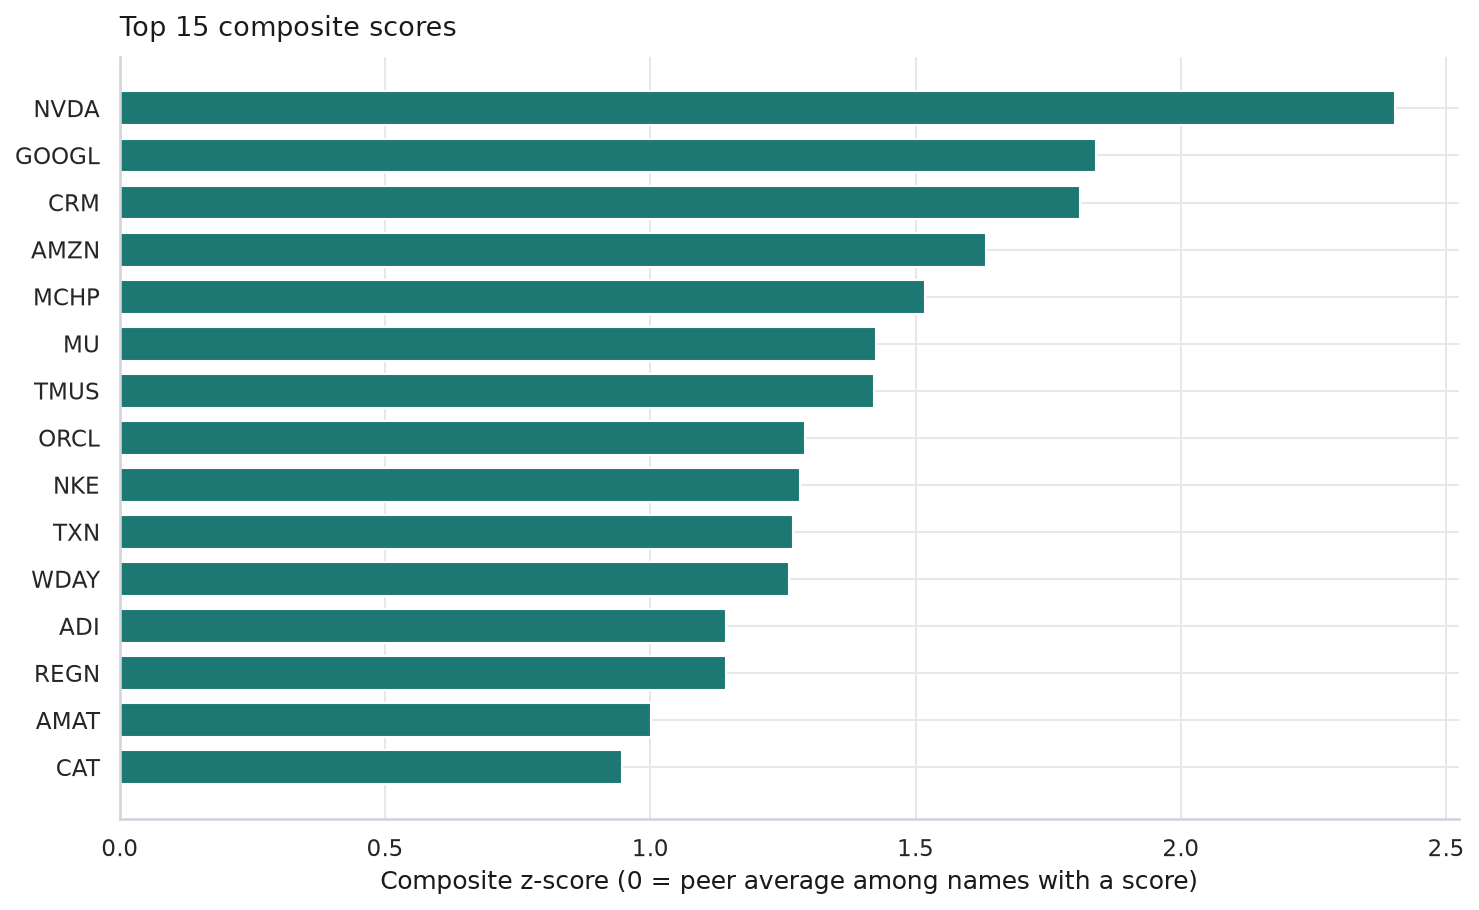

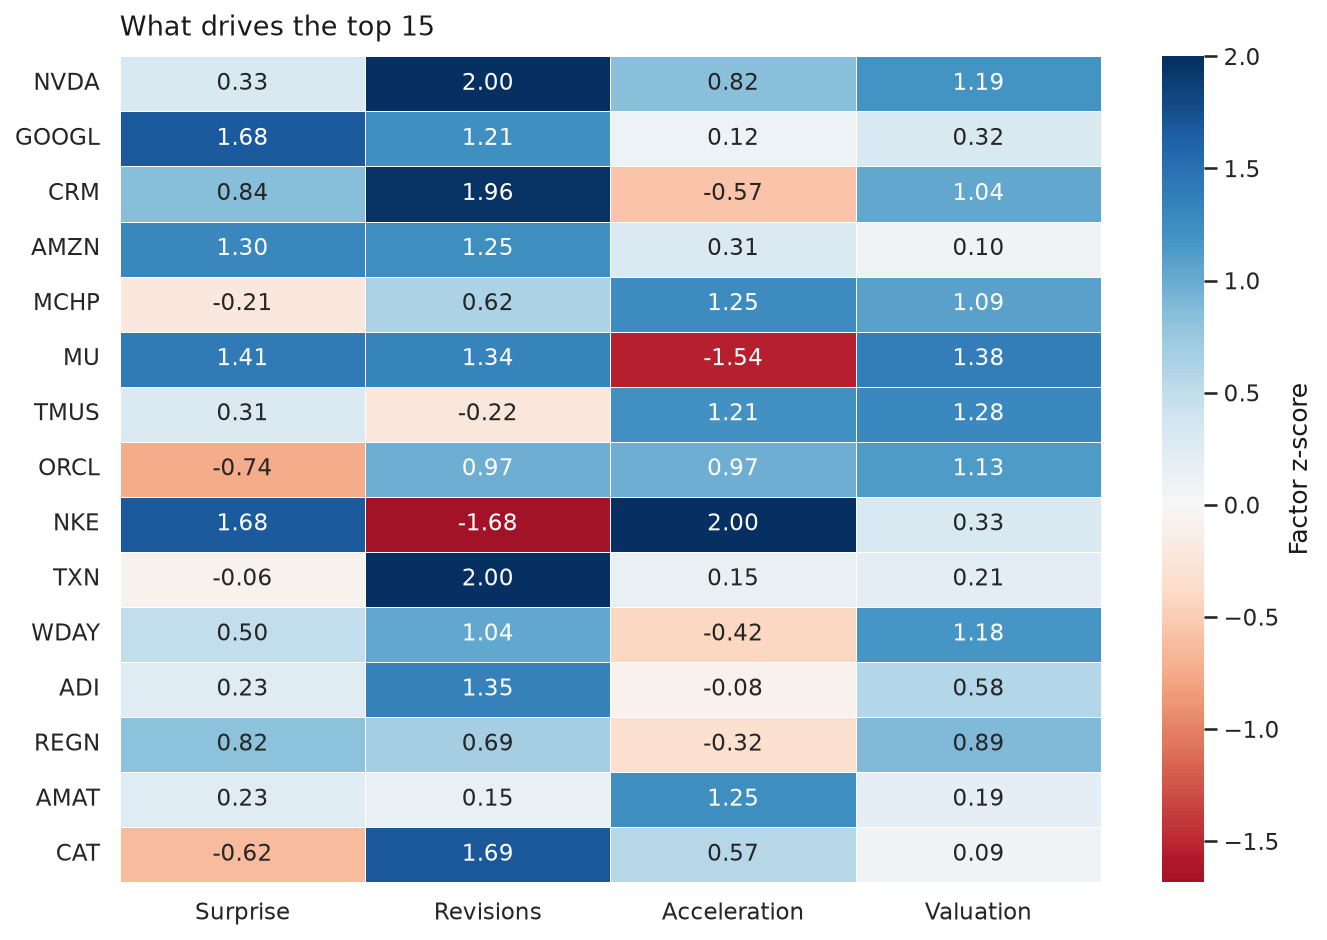

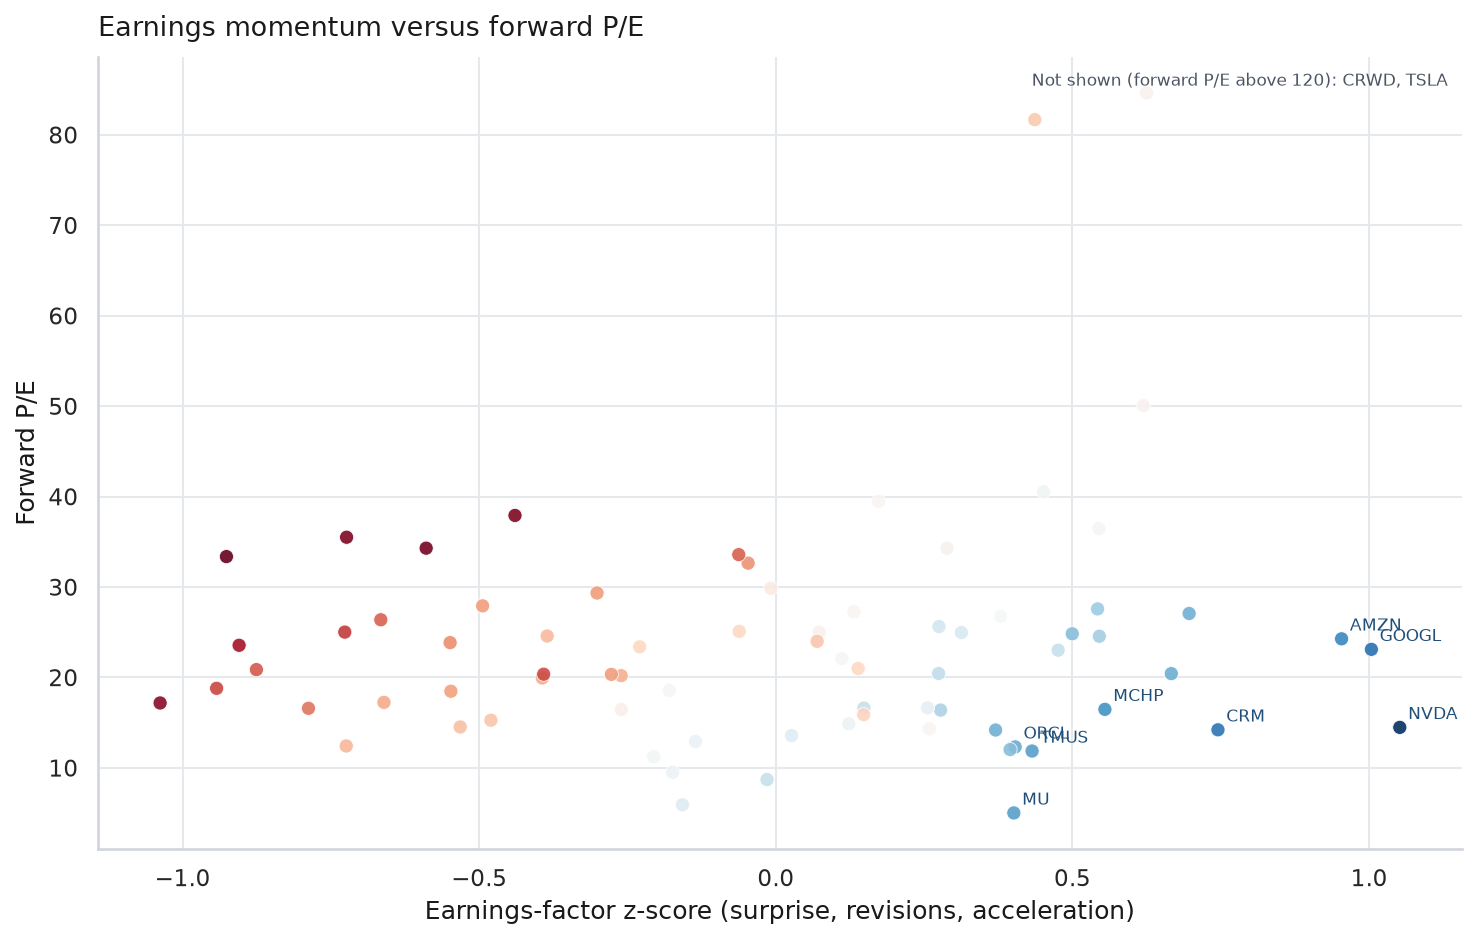

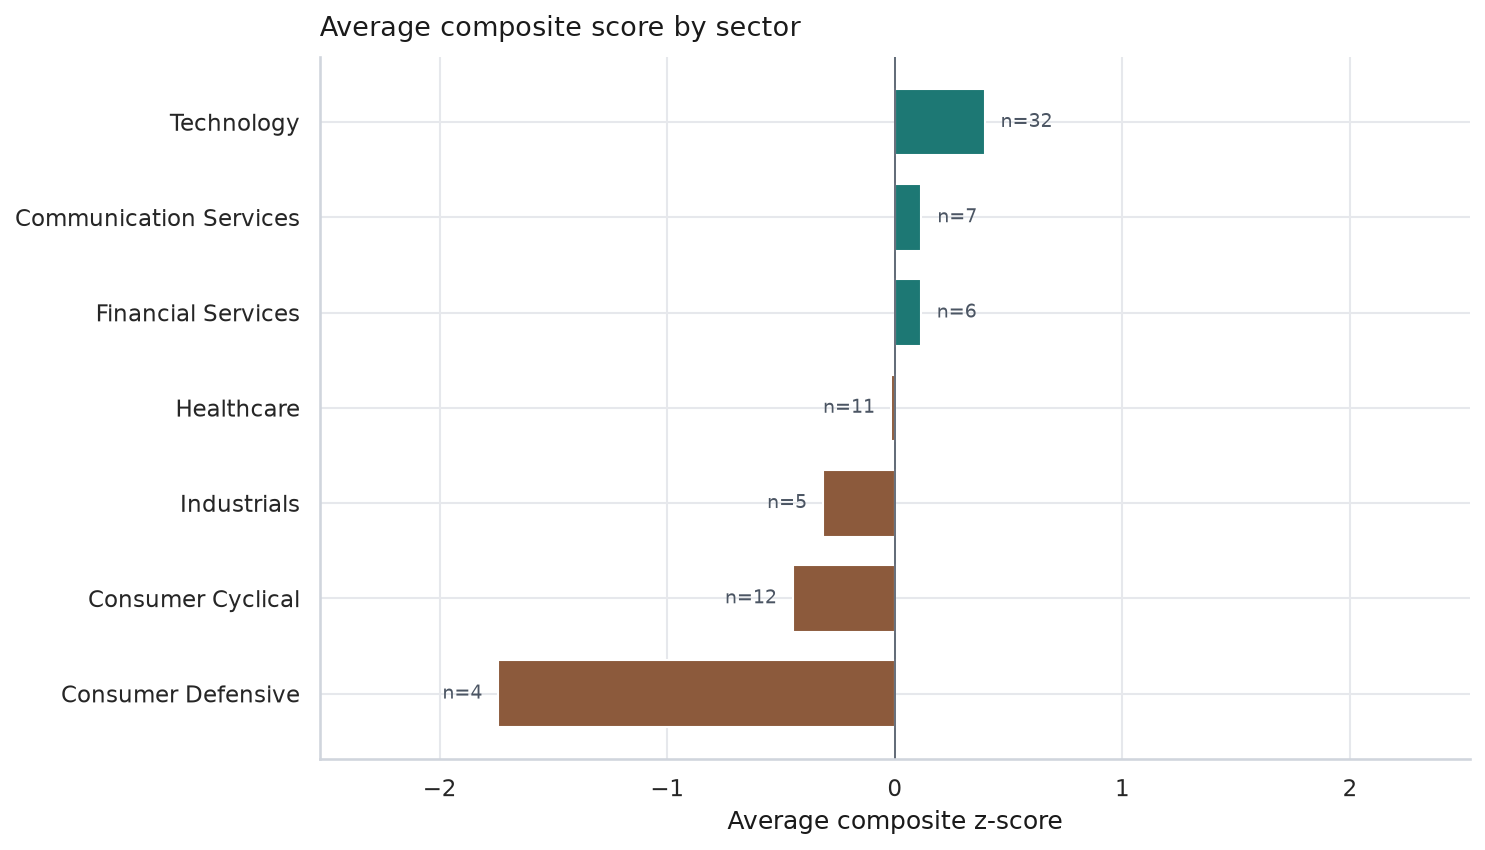

In [10]:
for name in [
    "01_composite_ranking.png",
    "02_factor_heatmap.png",
    "03_momentum_vs_valuation.png",
    "06_sector_scores.png",
]:
    display(Image(filename=str(ROOT / "images" / name)))


The heatmap is the page to talk through. NVIDIA is strong on revisions and valuation. Nike is strong on surprise and acceleration and weak on revisions. Micron is strong on surprise, revisions, and valuation, and weak on acceleration.

The scatter plots an earnings-factor score (surprise, revisions, acceleration) against forward P/E. CrowdStrike and Tesla are left off the axes because their forward P/E is above 120; the note on the chart says so. A point in the lower right is the GARP combination this process is looking for: earnings momentum with a lower multiple.

Sector bars are tilts around zero, because the composite was re-centered on the whole universe. Technology is the positive tilt. Consumer defensive, four names, is the negative tilt.


## 7. Backtest design

At each quarter-end from 30 September 2021 through 30 June 2026, a stock with four already-reported usable surprises is scored on the average capped surprise over those four quarters. Five equal-weight quintiles. Quintile 5 is the highest surprise. Hold to the next quarter-end, through 30 September 2026.

The return starts at the quarter-end close. The signal does not use a print that was not yet available. Revisions and valuation from the October 2026 snapshot are not used. Putting them into 2022 would be look-ahead.

The equal-weight universe is every name with a signal that quarter. IWF is the Russell 1000 Growth ETF, held over the same dates, on dividend-adjusted prices. IWF is a proxy for the index: it has a fee, tracking difference, and cap weights.


In [11]:
view = stats.copy()
pct_cols = [
    "cagr", "ann_vol", "max_drawdown", "hit_rate_positive",
    "hit_rate_vs_equal_weight", "hit_rate_vs_iwf",
    "avg_quarter_return", "total_return",
]
for col in pct_cols:
    view[col] = (view[col] * 100).round(2)
view["sharpe_rf0"] = view["sharpe_rf0"].round(2)
view = view.rename(columns={
    "cagr": "CAGR %",
    "ann_vol": "Vol %",
    "sharpe_rf0": "Sharpe rf=0",
    "max_drawdown": "Max DD %",
    "hit_rate_positive": "Quarters up %",
    "hit_rate_vs_equal_weight": "Beat EW %",
    "hit_rate_vs_iwf": "Beat IWF %",
    "avg_quarter_return": "Avg quarter %",
    "total_return": "Total return %",
})
display(view)

sk = summary["sklearn"]
spread = summary["spread"]
print(f"Q5 minus Q1, average quarterly gap: {spread['mean_q5_minus_q1']*100:.1f} percentage points")
print(f"Descriptive t-statistic on that gap: {spread['tstat_descriptive']:.2f} over {spread['n_quarters']} quarters")
print(f"Q5 minus Q1 excess return, first half: {sk['q5_minus_q1_excess_first_half']*100:.1f} pp per quarter")
print(f"Q5 minus Q1 excess return, second half: {sk['q5_minus_q1_excess_second_half']*100:.1f} pp per quarter")
print(f"Regression slope, full sample: {sk['coef_full_sample']*100:.2f} pp of excess return per surprise z-score")
print(f"Out-of-sample R-squared (fit before {sk['train_end_exclusive']}): {sk['r2_test']:.4f}")
print(f"Spearman correlation, surprise z-score vs excess return: {sk['spearman_signal_excess']:.3f}")


,portfolio,months,quarters,CAGR %,Vol %,Sharpe rf=0,Max DD %,Quarters up %,Beat EW %,Beat IWF %,Avg quarter %,Total return %
0,Q5,60,20,23.87,21.03,1.13,-26.88,75.00,55.00,75.00,6.15,191.58
1,Q4,60,20,10.23,19.33,0.60,-30.73,65.00,30.00,50.00,2.97,62.76
2,Q3,60,20,23.82,19.83,1.18,-23.89,70.00,60.00,65.00,6.12,191.02
3,Q2,60,20,14.40,17.84,0.85,-28.56,60.00,30.00,55.00,3.82,95.98
4,Q1,60,20,19.01,18.60,1.03,-20.43,60.00,60.00,60.00,4.86,138.73
5,Equal-weight universe,60,20,18.66,17.85,1.05,-25.57,70.00,NaN,75.00,4.79,135.23
6,IWF,60,20,13.48,19.27,0.75,-30.75,70.00,NaN,NaN,3.75,88.19


Q5 minus Q1, average quarterly gap: 1.3 percentage points
Descriptive t-statistic on that gap: 0.61 over 20 quarters
Q5 minus Q1 excess return, first half: -1.3 pp per quarter
Q5 minus Q1 excess return, second half: 4.0 pp per quarter
Regression slope, full sample: 0.12 pp of excess return per surprise z-score
Out-of-sample R-squared (fit before 2024-03-31): -0.0000
Spearman correlation, surprise z-score vs excess return: -0.009


## 8. Backtest charts

Sharpe uses a zero risk-free rate: average monthly return divided by its standard deviation, times √12. Over 2021–2026, T-bills paid more than zero, so this ratio is higher than a textbook excess-return Sharpe. Max drawdown is the deepest loss on the monthly wealth curve. A daily curve would be at least as deep.

Q3 is drawn on the wealth chart because it finished almost on top of Q5. The bar chart is not a staircase. Q4's average quarter is the weakest of the five.


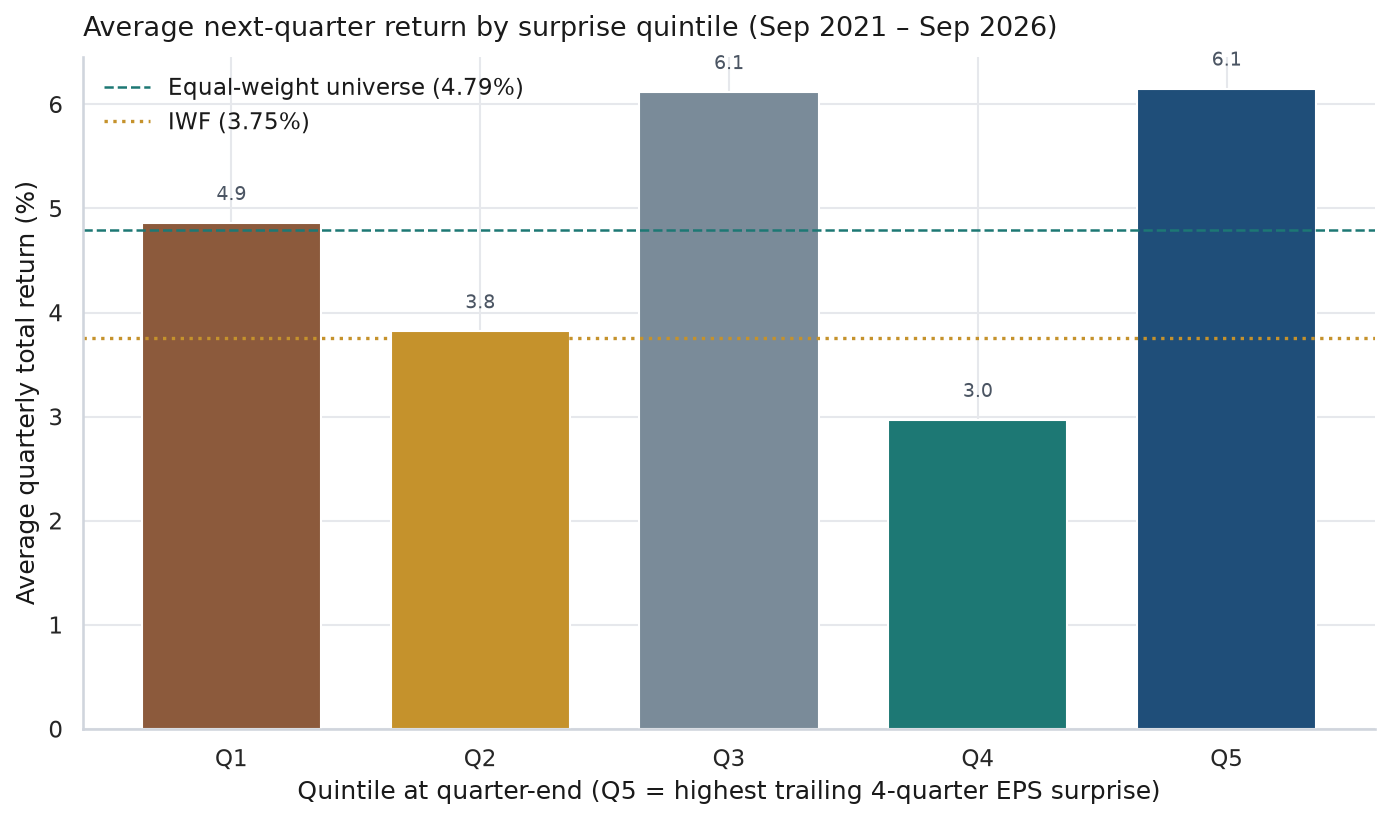

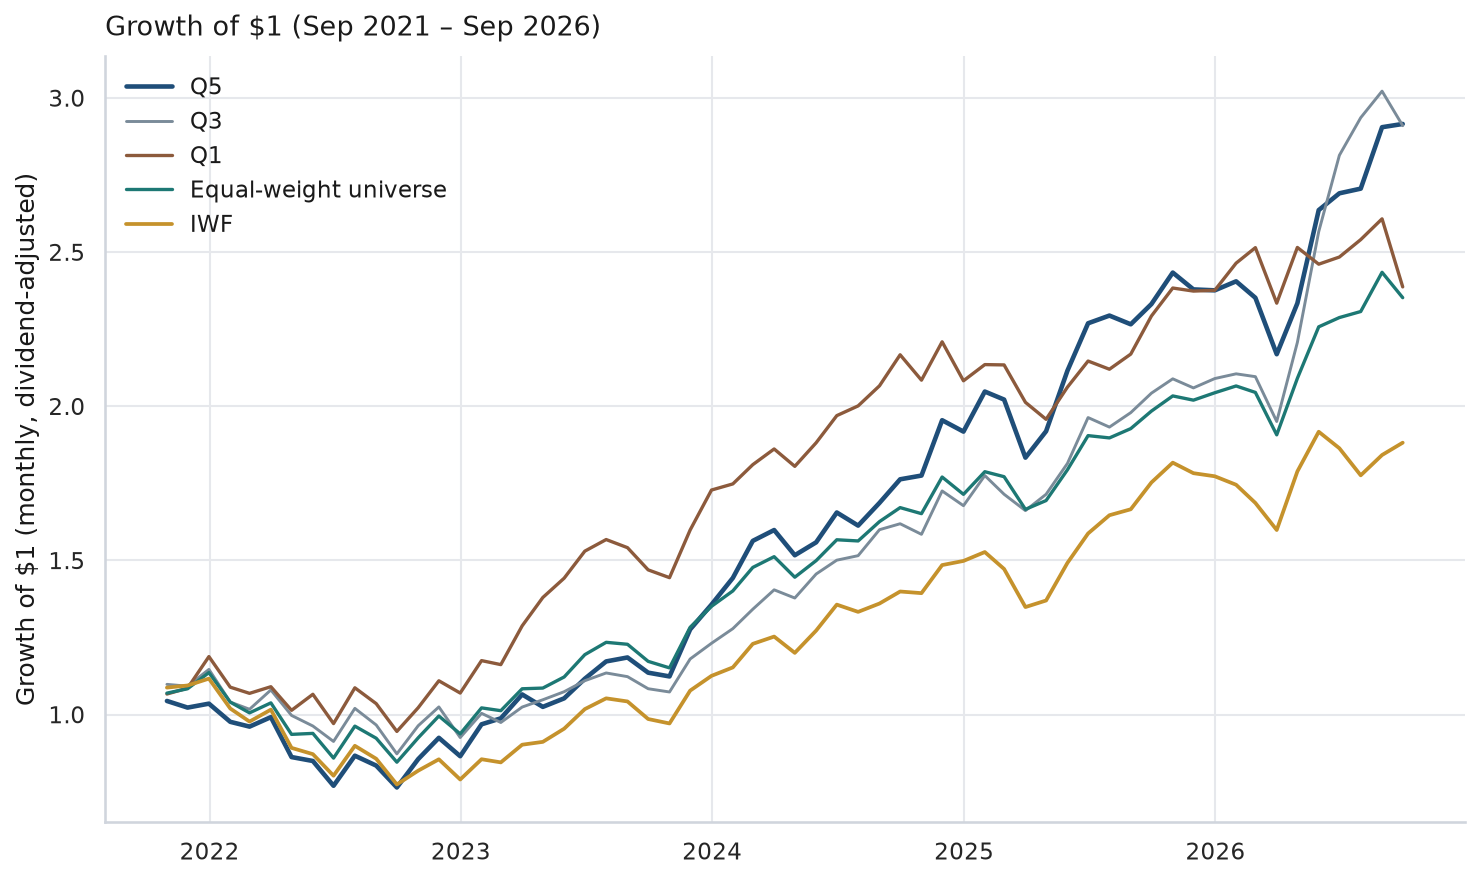

In [12]:
for name in ["04_quintile_returns.png", "05_cumulative_returns.png"]:
    display(Image(filename=str(ROOT / "images" / name)))


## 9. What to say about the result

On the 8 October 2026 snapshot the reading list starts with NVIDIA, Alphabet, Salesforce, Amazon, and Microchip Technology. The cleanest revision stories on the page are NVIDIA (43 raises and 1 cut over 30 days), Salesforce (48 raises and 0 cuts), and Texas Instruments (25 raises and 0 cuts). Alphabet and Amazon need an EPS bridge before the current-year estimate is treated as a run rate, because next year's consensus is below this year's. Nike fails a "estimates must be rising" check. Micron's forward P/E near 5 needs a mid-cycle earnings number before it means "cheap."

From September 2021 through September 2026 the highest-surprise quintile compounded at about 23.9% a year, the equal-weight universe at about 18.7%, and IWF at about 13.5%. The top quintile beat IWF in 75% of quarters and beat the equal-weight universe in 55%. The third quintile compounded at about 23.8%. The Q5-minus-Q1 gap averages about 1.3 percentage points a quarter, with a descriptive t-statistic near 0.6, and the sign of that gap flips between the first half of the sample and the second. The out-of-sample R² is about zero.

The equal-weight universe itself beat IWF by more than the top quintile beat the equal-weight universe. Every name here is a company that was still a large cap when the file was pulled. IWF is a live cap-weighted ETF. Compare quintiles to the equal-weight universe when the question is whether the surprise sort added anything.

Nothing in this notebook is a position size. A book built from the list would still need a limit on a single name, a limit on technology (12 of the top 20 are technology), and a check that a low multiple is not peak earnings.
